In [2]:
# 데이터 처리 및 분석
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings

# 경로 설정
import os 
import sys

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns

# 출력 설정
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# 한글 폰트 설정
import platform
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12,6)

# 시드 설정
np.random.seed(42)

print('-' * 60)
print('라이브러리 로드 완료')
print('한글 폰트 설정 완료!')
print('-'* 60)

------------------------------------------------------------
라이브러리 로드 완료
한글 폰트 설정 완료!
------------------------------------------------------------


In [3]:
# 현재 작업 디렉토리(notebooks)의 부모 디렉토리(root)를 경로에 추가
os.chdir(os.path.abspath('..'))
print(os.getcwd())

df = pd.read_csv('data/2025_Airbnb_NYC_listings.csv').drop(columns = 'Unnamed: 0')
df.head()

c:\Users\kims\Documents\airbnb_price_prediction


,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,36121,city scrape,Lg Rm in Historic Prospect Heights,Cozy space share in the heart of a great neigh...,Full of tree-lined streets and beautiful brown...,62165,Michael,2009-12-11,"New York, NY",I’m an urban planner working for an internatio...,NaN,NaN,NaN,f,Prospect Heights,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Prospect Heights,Brooklyn,40.673760,-73.966110,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Refrigerator"", ""Dishes and silverware"", ""Wif...",$200.00,90,365,90.0,90.0,365.0,365.0,90.0,365.0,NaN,t,27,57,87,362,2025-03-03,9,0,0,301,0,0,0.0,2010-12-11,2013-05-10,4.88,5.00,4.80,5.00,5.00,5.00,5.00,NaN,f,1,0,1,0,0.05
1,36647,city scrape,"1 Bedroom & your own Bathroom, Elevator Apartment",Private bedroom with your own bathroom in a 2 ...,"Manhattan, SE corner of 2nd Ave/ E. 110th street",157798,Irene,2010-07-04,"New York, NY",NaN,NaN,NaN,100%,f,East Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,East Harlem,Manhattan,40.792454,-73.940742,Private room in condo,Private room,2,1.0,1 private bath,1.0,1.0,"[""Oven"", ""Blender"", ""Luggage dropoff allowed"",...",$82.00,30,999,30.0,30.0,999.0,999.0,30.0,999.0,NaN,t,0,0,0,204,2025-03-03,102,0,0,143,0,0,0.0,2010-10-04,2023-12-09,4.77,4.82,4.76,4.88,4.90,4.38,4.71,NaN,f,1,0,1,0,0.58
2,38663,city scrape,Luxury Brownstone in Boerum Hill,"Beautiful, large home in great hipster neighbo...","diverse, lively, hip, cool: loaded with restau...",165789,Sarah,2010-07-13,"New York, NY",I am a lawyer and work as an executive at an a...,within a few hours,100%,40%,f,Boerum Hill,1.0,3.0,"['email', 'phone', 'work_email']",t,t,Neighborhood highlights,Boerum Hill,Brooklyn,40.684420,-73.980680,Private room in home,Private room,2,2.5,2.5 baths,5.0,5.0,"[""Portable fans"", ""Oven"", ""Baking sheet"", ""Fir...",$765.00,3,60,3.0,3.0,60.0,60.0,3.0,60.0,NaN,t,30,49,66,326,2025-03-02,43,0,0,267,0,0,0.0,2012-07-09,2023-08-30,4.70,4.83,4.52,4.88,4.88,4.86,4.62,OSE-STRREG-0001784,f,1,0,1,0,0.28
3,38833,city scrape,Spectacular West Harlem Garden Apt,This is a very large and unique space. An inc...,West Harlem is now packed with great restauran...,166532,Matthew,2010-07-14,"New York, NY",I have been a New Yorker for a long time\n and...,within an hour,100%,97%,t,Harlem,1.0,1.0,"['email', 'phone']",t,t,Neighborhood highlights,Harlem,Manhattan,40.818058,-73.946671,Entire home,Entire home/apt,2,1.0,1 bath,1.0,1.0,"[""Fire extinguisher"", ""Clothing storage: close...",$139.00,2,45,2.0,2.0,1125.0,1125.0,2.0,1125.0,NaN,t,7,18,25,25,2025-03-03,241,42,3,25,43,255,35445.0,2010-08-28,2025-02-21,4.85,4.87,4.50,4.96,4.96,4.79,4.82,OSE-STRREG-0000476,

In [4]:
# 특정 컬럼의 결측치 개수
df['host_identity_verified'].isnull().sum()
print(f"host_identity_verified 컬럼의 결측치 개수: {df['host_identity_verified'].isnull().sum()}")
# 특정 컬럼의 결측치 비율(%)
df['host_identity_verified'].isnull().mean() * 100
print(f"host_identity_verified 컬럼의 결측치 비율: {df['host_identity_verified'].isnull().mean() * 100:.2f}%")
# 최빈값(결측치 제외)
mode_value = df['host_identity_verified'].mode()
print(f"host_identity_verified 컬럼의 최빈값: {mode_value[0] if not mode_value.empty else 'No mode found'}")
# 최빈값의 개수 및 비율
mode_count = df['host_identity_verified'].value_counts().iloc[0]
mode_percentage = (mode_count / len(df)) * 100
print(f"host_identity_verified 컬럼의 최빈값 개수: {mode_count}")
print(f"host_identity_verified 컬럼의 최빈값 비율: {mode_percentage:.2f}%")

# 특정 컬럼만 필터링해서 보기
df['host_identity_verified'].value_counts()

host_identity_verified 컬럼의 결측치 개수: 20
host_identity_verified 컬럼의 결측치 비율: 0.09%
host_identity_verified 컬럼의 최빈값: t
host_identity_verified 컬럼의 최빈값 개수: 20423
host_identity_verified 컬럼의 최빈값 비율: 91.55%


host_identity_verified
t    20423
f     1865
Name: count, dtype: int64

In [5]:
# 특정 컬럼의 결측치 개수
df['host_has_profile_pic'].isnull().sum()
print(f"host_has_profile_pic 컬럼의 결측치 개수: {df['host_has_profile_pic'].isnull().sum()}")
# 특정 컬럼의 결측치 비율(%)
df['host_has_profile_pic'].isnull().mean() * 100
print(f"host_has_profile_pic 컬럼의 결측치 비율: {df['host_has_profile_pic'].isnull().mean() * 100:.2f}%")
# 최빈값(결측치 제외)
mode_value = df['host_has_profile_pic'].mode()
print(f"host_has_profile_pic 컬럼의 최빈값: {mode_value[0] if not mode_value.empty else 'No mode found'}")
# 최빈값의 개수 및 비율
mode_count = df['host_has_profile_pic'].value_counts().iloc[0]
mode_percentage = (mode_count / len(df)) * 100
print(f"host_has_profile_pic 컬럼의 최빈값 개수: {mode_count}")
print(f"host_has_profile_pic 컬럼의 최빈값 비율: {mode_percentage:.2f}%")

# 특정 컬럼만 필터링해서 보기
df['host_has_profile_pic'].value_counts()

host_has_profile_pic 컬럼의 결측치 개수: 20
host_has_profile_pic 컬럼의 결측치 비율: 0.09%
host_has_profile_pic 컬럼의 최빈값: t
host_has_profile_pic 컬럼의 최빈값 개수: 21646
host_has_profile_pic 컬럼의 최빈값 비율: 97.03%


host_has_profile_pic
t    21646
f      642
Name: count, dtype: int64

In [6]:
# 특정 컬럼의 결측치 개수
df['host_verifications'].isnull().sum()
print(f"host_verifications 컬럼의 결측치 개수: {df['host_verifications'].isnull().sum()}")
# 특정 컬럼의 결측치 비율(%)
df['host_verifications'].isnull().mean() * 100
print(f"host_verifications 컬럼의 결측치 비율: {df['host_verifications'].isnull().mean() * 100:.2f}%")
# 최빈값(결측치 제외)
mode_value = df['host_verifications'].mode()
print(f"host_verifications 컬럼의 최빈값: {mode_value[0] if not mode_value.empty else 'No mode found'}")
# 최빈값의 개수 및 비율
mode_count = df['host_verifications'].value_counts().iloc[0]
mode_percentage = (mode_count / len(df)) * 100
print(f"host_verifications 컬럼의 최빈값 개수: {mode_count}")
print(f"host_verifications 컬럼의 최빈값 비율: {mode_percentage:.2f}%")

# 특정 컬럼만 필터링해서 보기
df['host_verifications'].value_counts()
# 특정 컬럼 중 특정 응답만 필터링해서 보기
cols = df.filter(like='host_verifications').columns

df[
    df[cols].isna().any(axis=1) |
    (df[cols] == '[]').any(axis=1)
]

host_verifications 컬럼의 결측치 개수: 20
host_verifications 컬럼의 결측치 비율: 0.09%
host_verifications 컬럼의 최빈값: ['email', 'phone']
host_verifications 컬럼의 최빈값 개수: 16852
host_verifications 컬럼의 최빈값 비율: 75.54%


,id,source,name,description,neighborhood_overview,host_id,host_name,host_since,host_location,host_about,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_neighbourhood,host_listings_count,host_total_listings_count,host_verifications,host_has_profile_pic,host_identity_verified,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,longitude,property_type,room_type,accommodates,bathrooms,bathrooms_text,bedrooms,beds,amenities,price,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,calendar_updated,has_availability,availability_30,availability_60,availability_90,availability_365,calendar_last_scraped,number_of_reviews,number_of_reviews_ltm,number_of_reviews_l30d,availability_eoy,number_of_reviews_ly,estimated_occupancy_l365d,estimated_revenue_l365d,first_review,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
229,302758,city scrape,Sunny 1BR East Harlem Apartment,Two-room apartment in East Harlem. Close to su...,"Ethnic diversity, proximity to subway and buse...",8605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,Neighborhood highlights,East Harlem,Manhattan,40.796750,-73.936340,Entire rental unit,Entire home/apt,2,1.0,1 bath,1.0,2.0,"[""Air conditioning"", ""Wifi"", ""Smoke alarm"", ""K...",$150.00,30,60,30.0,30.0,60.0,60.0,30.0,60.0,NaN,t,28,58,88,88,2025-03-02,12,0,0,88,0,0,0.0,2012-09-04,2016-03-26,4.50,4.58,3.58,4.83,4.75,3.83,4.17,NaN,f,1,1,0,0,0.08
1452,7037918,city scrape,"Near LGA, Citifield, US Open Tennis","Comfortable, sunny, cozy bedroom in private ho...",We live in a quiet residential neighborhood ne...,36242220,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,Neighborhood highlights,East Elmhurst,Queens,40.765500,-73.865770,Private room in home,Private room,2,1.0,1 shared bath,1.0,1.0,"[""Fire extinguisher"", ""Luggage dropoff allowed...",$70.00,30,1125,30.0,30.0,1125.0,1125.0,30.0,1125.0,NaN,t,30,60,90,365,2025-03-03,229,0,0,304,0,0,0.0,2015-08-09,2020-01-01,4.77,4.87,4.76,4.91,4.93,4.87,4.76,NaN,f,1,0,1,0,1.97
2943,20193830,city scrape,Family brownstone with backyard,"Located in Clinton Hill, a historic Brooklyn n...",NaN,1294005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,t,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Clinton Hill,Brooklyn,40.687851,-73.964070,Entire rental unit,Entire home/apt,5,2.0,2 baths,3.0,4.0,"[""Portable fans"", ""Baking sheet"", ""Garden view...",$614.00,2,365,2.0,2.0,365.0,365.0,2.0,365.0,NaN,t,8,14,20,178,2025-03-02,113,34,0,125,35,255,156570.0,2017-09-05,2025-01-27,4.98,4.98,4.90,4.99,4.98,4.96,4.88,OSE-STRREG-0000992,f,1,1,0,0,1.24
3161,21802923,city scrape,Private Bedroom with Private Entrance in Brook...,You will have a large bedroom with a private e...,My personal faves in the area.<br /><br />Coff...,72466752,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,Neighborhood highlights,Bushwick,Brooklyn,40.701310,-73.917830,Private room in rental unit,Private room,1,1.0,1 shared bath,1.0,1.0,"[""Oven"", ""Laundromat nearby"", ""Blender"", ""Dedi...",$75.00,30,1125,30.0,30.0,1125.0,1125.0,30.0,1125.0,NaN,t,30,60,90,270,2025-03-02,54,0,0,270,0,0,0.0,2017-12-11,2023-10-10,4.69,4.72,4.52,4.78,4.80,4.85,4.65,NaN,f,1,0,1,0,0.61
6090,45189535,city scrape,Private Room for Sleeping in Great Neighborhood,"Safe, quiet, private, NYC room available just ...",One of the Best neighborhoods in Manhattan! Cl...,364960386,NaN,NaN,NaN,NaN,NaN,NaN,NaN,f,NaN,NaN,NaN,NaN,NaN,NaN,Neighborhood highlights,Upper West Side,Manhattan,40.788340,-73.980060,Private room in rental unit,Private room,1,1.0,1 shared bath,2.0,1.0,"[""Portab

In [7]:
# 특정 컬럼의 결측치 개수
df['host_total_listings_count'].isnull().sum()
print(f"host_total_listings_count 컬럼의 결측치 개수: {df['host_total_listings_count'].isnull().sum()}")
# 특정 컬럼의 결측치 비율(%)
df['host_total_listings_count'].isnull().mean() * 100
print(f"host_total_listings_count 컬럼의 결측치 비율: {df['host_total_listings_count'].isnull().mean() * 100:.2f}%")
# 최빈값(결측치 제외)
mode_value = df['host_total_listings_count'].mode()
print(f"host_total_listings_count 컬럼의 최빈값: {mode_value[0] if not mode_value.empty else 'No mode found'}")
# 최빈값의 개수 및 비율
mode_count = df['host_total_listings_count'].value_counts().iloc[0]
mode_percentage = (mode_count / len(df)) * 100
print(f"host_total_listings_count 컬럼의 최빈값 개수: {mode_count}")
print(f"host_total_listings_count 컬럼의 최빈값 비율: {mode_percentage:.2f}%")

# 특정 컬럼만 필터링해서 보기
df['host_total_listings_count'].value_counts()

# 전체 호스트 중 가장 많은 숙소 개수 확인
max_listings = df['host_total_listings_count'].max()
print(f"숙소 개수 최대값: {max_listings}")

# 숙소 개수 구간 정의
bins = [0, 1, 2, 5, 10, 50, 100, 1000, 5000, 9000, np.inf]
labels = ['1개', '2개', '3-5개', '6-10개', '11-50개', '51-100개', '100-1000개', '1001-5000개', '5001-9000개', '9000개 초과']

# 구간별 분포 확인
df['host_type_category'] = pd.cut(df['host_total_listings_count'], bins=bins, labels=labels)
print(df['host_type_category'].value_counts().sort_index())

host_total_listings_count 컬럼의 결측치 개수: 20
host_total_listings_count 컬럼의 결측치 비율: 0.09%
host_total_listings_count 컬럼의 최빈값: 1.0
host_total_listings_count 컬럼의 최빈값 개수: 3989
host_total_listings_count 컬럼의 최빈값 비율: 17.88%
숙소 개수 최대값: 9055.0
host_type_category
1개            3989
2개            2847
3-5개          4488
6-10개         2620
11-50개        3530
51-100개        836
100-1000개     1839
1001-5000개     511
5001-9000개    1605
9000개 초과        23
Name: count, dtype: int64


In [16]:
# 특정 컬럼의 결측치 개수
df['host_listings_count'].isnull().sum()
print(f"host_listings_count 컬럼의 결측치 개수: {df['host_listings_count'].isnull().sum()}")
# 특정 컬럼의 결측치 비율(%)
df['host_listings_count'].isnull().mean() * 100
print(f"host_listings_count 컬럼의 결측치 비율: {df['host_listings_count'].isnull().mean() * 100:.2f}%")
# 최빈값(결측치 제외)
mode_value = df['host_listings_count'].mode()
print(f"host_listings_count 컬럼의 최빈값: {mode_value[0] if not mode_value.empty else 'No mode found'}")
# 최빈값의 개수 및 비율
mode_count = df['host_listings_count'].value_counts().iloc[0]
mode_percentage = (mode_count / len(df)) * 100
print(f"host_listings_count 컬럼의 최빈값 개수: {mode_count}")
print(f"host_listings_count 컬럼의 최빈값 비율: {mode_percentage:.2f}%")

# 특정 컬럼만 필터링해서 보기
df['host_listings_count'].value_counts()

# 전체 호스트 중 가장 많은 숙소 개수 확인
max_listings = df['host_listings_count'].max()
print(f"숙소 개수 최대값: {max_listings}")

# 숙소 개수 구간 정의
bins = [0, 1, 2, 5, 10, 50, 100, 1000, 3000, 5000, np.inf]
labels = ['1개', '2개', '3-5개', '6-10개', '11-50개', '51-100개', '100-1000개', '1001-3000개', '3001-5000개', '5000개 초과']

# 구간별 분포 확인
df['host_registration_type_category'] = pd.cut(df['host_listings_count'], bins=bins, labels=labels)
print(df['host_registration_type_category'].value_counts().sort_index())

host_listings_count 컬럼의 결측치 개수: 20
host_listings_count 컬럼의 결측치 비율: 0.09%
host_listings_count 컬럼의 최빈값: 1.0
host_listings_count 컬럼의 최빈값 개수: 6791
host_listings_count 컬럼의 최빈값 비율: 30.44%
숙소 개수 최대값: 5255.0
host_registration_type_category
1개            6791
2개            2983
3-5개          3337
6-10개         1967
11-50개        2830
51-100개        860
100-1000개     1782
1001-3000개     137
3001-5000개     507
5000개 초과      1094
Name: count, dtype: int64


In [17]:
# 특정 컬럼의 결측치 개수
df['host_listings_count'].isnull().sum()
print(f"host_listings_count 컬럼의 결측치 개수: {df['host_listings_count'].isnull().sum()}")
# 특정 컬럼의 결측치 비율(%)
df['host_listings_count'].isnull().mean() * 100
print(f"host_listings_count 컬럼의 결측치 비율: {df['host_listings_count'].isnull().mean() * 100:.2f}%")
# 최빈값(결측치 제외)
mode_value = df['host_listings_count'].mode()
print(f"host_listings_count 컬럼의 최빈값: {mode_value[0] if not mode_value.empty else 'No mode found'}")
# 최빈값의 개수 및 비율
mode_count = df['host_listings_count'].value_counts().iloc[0]
mode_percentage = (mode_count / len(df)) * 100
print(f"host_listings_count 컬럼의 최빈값 개수: {mode_count}")
print(f"host_listings_count 컬럼의 최빈값 비율: {mode_percentage:.2f}%")
# 특정 컬럼만 필터링해서 보기
df['host_listings_count'].value_counts()

host_listings_count 컬럼의 결측치 개수: 20
host_listings_count 컬럼의 결측치 비율: 0.09%
host_listings_count 컬럼의 최빈값: 1.0
host_listings_count 컬럼의 최빈값 개수: 6791
host_listings_count 컬럼의 최빈값 비율: 30.44%


host_listings_count
1.0       6791
2.0       2983
3.0       1588
4.0       1096
5255.0    1094
          ... 
187.0        1
270.0        1
328.0        1
114.0        1
60.0         1
Name: count, Length: 109, dtype: int64

In [21]:
df['property_type'].unique()

<StringArray>
[       'Private room in rental unit',              'Private room in condo',
               'Private room in home',                        'Entire home',
                 'Entire rental unit',        'Private room in guest suite',
                       'Entire place',                        'Entire loft',
                       'Entire condo',          'Private room in townhouse',
                   'Entire townhouse',  'Private room in bed and breakfast',
          'Entire serviced apartment',               'Private room in loft',
                  'Entire guesthouse',                 'Entire guest suite',
          'Private room in houseboat',             'Room in boutique hotel',
                       'Private room',         'Shared room in rental unit',
                               'Boat',         'Room in serviced apartment',
              'Private room in villa', 'Private room in religious building',
                    'Casa particular',                'Shared 

In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 22308 entries, 0 to 22307
Data columns (total 74 columns):
 #   Column                                        Non-Null Count  Dtype         
---  ------                                        --------------  -----         
 0   id                                            22308 non-null  int64         
 1   source                                        22308 non-null  str           
 2   name                                          22308 non-null  str           
 3   description                                   21903 non-null  str           
 4   neighborhood_overview                         12262 non-null  str           
 5   host_id                                       22308 non-null  int64         
 6   host_name                                     22288 non-null  str           
 7   host_since                                    22288 non-null  datetime64[us]
 8   host_location                                 17025 non-null  str           


In [19]:
df.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
id,22308.0,NaN,NaN,NaN,594931827143523456.0,6848.0,41372693.25,727563706116818176.0,1067266443718449536.0,1366912874990325504.0,516864910912614336.0
source,22308,1,city scrape,22308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,22308,21342,Wyndham Midtown 45 Resort | King Bed Hotel Room,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
description,21903,17854,Keep it simple at this peaceful and centrally-...,72,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighborhood_overview,12262,8232,This furnished property is located on the Uppe...,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,22308.0,NaN,NaN,NaN,216347621.868881,1678.0,27181542.0,137358866.0,415840703.0,681436540.0,202510512.17774
host_name,22288,5343,Blueground,1094,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_since,22288,NaN,NaN,NaN,2018-01-18 12:52:27.738693,2008-08-11 00:00:00,2015-02-07 00:00:00,2017-06-27 12:00:00,2021-07-29 00:00:00,2025-02-27 00:00:00,NaN
host_location,17025,421,"New York, NY",13441,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_about,13391,5804,"We’re Blueground, a global proptech company wi...",1094,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [20]:
# 1차 전처리 columns
drop_cols = ['source','calendar_updated','calendar_last_scraped']

convert_tf_cols = ['host_is_superhost', 'host_has_profile_pic',
                'host_identity_verified','has_availability',
                'instant_bookable']

df['price'] = df['price'].str.replace('$','').str.replace(',','').astype('float')

df['host_since'] = pd.to_datetime(df['host_since'])

# 처리 함수
def convert_tf(df, cols):
    for col in cols:
        df[col] = df[col].map({'t':True, 'f':False}).astype('boolean')

    return df

df_cleaned = convert_tf(df, convert_tf_cols)
df_cleaned = df_cleaned.drop(columns = drop_cols)

AttributeError: Can only use .str accessor with string values, not floating

In [ ]:
df_cleaned.shape

(22308, 71)

Successfully saved: docs/images/가격 히스토그램.png


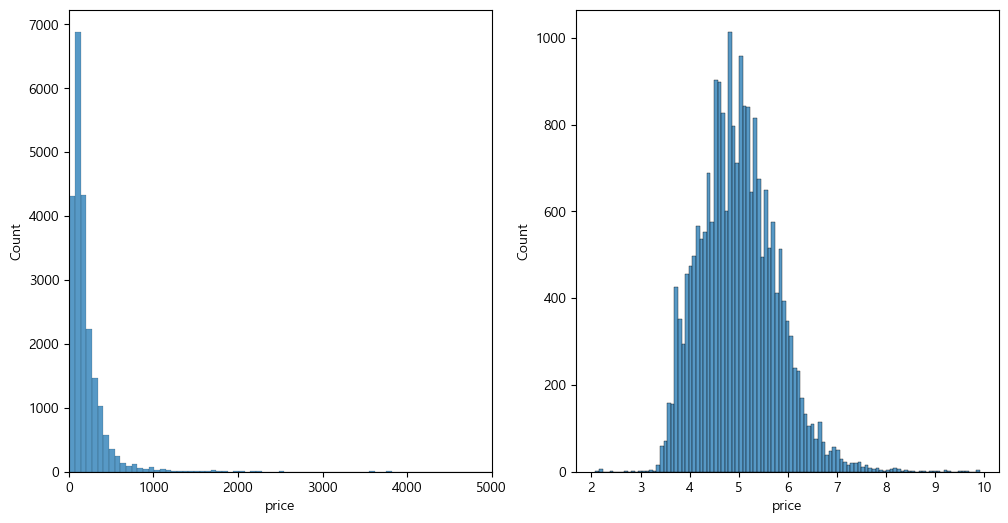

In [ ]:
from src import utils

fig, axs = plt.subplots(1,2)

sns.histplot(df_cleaned['price'], ax = axs[0])
axs[0].set_xlim(0,5000)

log_price = np.log(df_cleaned['price'] + 1)
sns.histplot(log_price, ax = axs[1])

utils.save_image(fig, '가격 히스토그램')

In [ ]:
from scipy.stats import shapiro, probplot

shapiro_stat, p_val = shapiro(log_price)
print('정규성 검정 결과:', p_val)

fig, axs = plt.subplots(1,2)

probplot(df_cleaned['price'], dist = 'norm', plot = axs[0])
probplot(log_price, dist = 'norm', plot = axs[1])
plt.tight_layout()
plt.show()

utils.save_image(fig, '가격 QQ plot')

print('왜도 : ', log_price.skew())
print('첨도 : ', log_price.kurt())

ModuleNotFoundError: No module named 'scipy'

In [ ]:
df_cleaned['log_price'] = np.log(df_cleaned['price'] + 1)
df_cleaned.shape

In [ ]:
import pydeck as pdk

plot_df = df_cleaned[['latitude','longitude','price','log_price']].dropna().copy()
plot_df = plot_df.reset_index(drop = True)

plot_df['color_rate'] = (plot_df['log_price'] / plot_df['log_price'].max() * 255).astype(int)

# 지도 중심점 표시
view_state = pdk.ViewState(
    latitude = plot_df['latitude'].mean(),
    longitude = plot_df['longitude'].mean(),
    zoom = 10,
    pitch = 30
)

# 위치별 가격 정보 시각화
column_layer = pdk.Layer(
    'ColumnLayer',
    plot_df.to_dict('records'),
    get_position = ['longitude','latitude'],
    get_elevation = 'price', # 높이는 price
    elevation_scale = 0.5,
    radius = 100,
    get_fill_color = '[255, color_rate, 0, 140]',
    pickable=True,
    auto_highlight=True
)

r = pdk.Deck(layers=[column_layer], initial_view_state=view_state)
r.to_html("docs/images/price_elevation.html", notebook_display=False)

In [ ]:
heatmap_layer = pdk.Layer(
    "HeatmapLayer",
    plot_df.to_dict('records'),
    get_position=["longitude", "latitude"],
    pickable = True,
    auto_highlight = True
)

r = pdk.Deck(layers=[heatmap_layer], initial_view_state=view_state)
r.to_html("docs/images/airbnb_heatmap.html", notebook_display = False)